In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from functools import partial
import importlib

import src.data
import src.features
import src.kernels
import src.krr
import src.svm
import src.metrics
import src.utils

from src.data import encode_labels, load_data, train_val_split
from src.features import HOG
from src.kernels import *
from src.krr import KernelRidgeRegression
from src.svm import KernelSVM
from src.metrics import accuracy
from src.utils import show_vector_image

In [3]:
DATA_DIR = "data/"

X_tr, X_te, y_tr_raw = load_data(DATA_DIR)

y_tr, inv_map = encode_labels(y_tr_raw)

n_classes = len(np.unique(y_tr))

Visualise an image

2


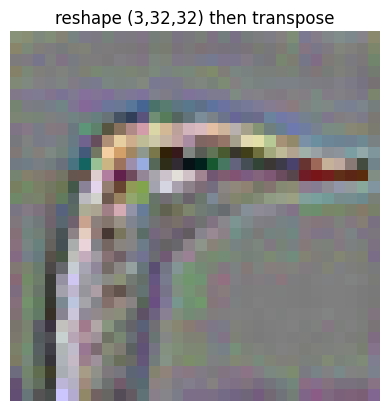

In [64]:
idx = 82
show_vector_image(X_tr[idx], index=idx, title="reshape (3,32,32) then transpose")
print(y_tr[idx])

### HOG

In [ ]:
hog = HOG(
    image_shape=(3, 32, 32),
    colour_mode="rgb",
    cell_size=8,
    block_size=2,
    block_stride=1,
    num_bins=6,
    signed=False,
).fit(X_tr)

X_tr_hog = hog.transform(X_tr)
X_te_hog = hog.transform(X_te)

X_train_hog, X_val_hog, y_train_hog, y_val_hog = train_val_split(
    X_tr_hog, y_tr, test_size=0.3, seed=20
)

#### Support Vector Machine

Linear kernel grid search

In [161]:
lrs = [0.6, 0.5, 0.4, 0.3, 0.2]
lams = [1e-4, 1e-5, 1e-6, 1e-7]

best = {"acc": -1.0, "lr": None, "lam": None}

for lr, lam in product(lrs, lams):
    kernel_fn = linear_kernel_matrix
    model = KernelSVM(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lr=lr,
        epochs=500,
        lam=lam,
        patience=5,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lr={lr:.1e}, lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lr": lr, "lam": lam}

print("best:", best)

lr=6.0e-01, lam=1.0e-04, val_acc=0.3747
lr=6.0e-01, lam=1.0e-05, val_acc=0.4307
lr=6.0e-01, lam=1.0e-06, val_acc=0.4613
lr=6.0e-01, lam=1.0e-07, val_acc=0.4573
lr=5.0e-01, lam=1.0e-04, val_acc=0.3753
lr=5.0e-01, lam=1.0e-05, val_acc=0.4320
lr=5.0e-01, lam=1.0e-06, val_acc=0.4613
lr=5.0e-01, lam=1.0e-07, val_acc=0.4553
lr=4.0e-01, lam=1.0e-04, val_acc=0.3733
lr=4.0e-01, lam=1.0e-05, val_acc=0.4313
lr=4.0e-01, lam=1.0e-06, val_acc=0.4613
lr=4.0e-01, lam=1.0e-07, val_acc=0.4573
lr=3.0e-01, lam=1.0e-04, val_acc=0.3747
lr=3.0e-01, lam=1.0e-05, val_acc=0.4313
lr=3.0e-01, lam=1.0e-06, val_acc=0.4613
lr=3.0e-01, lam=1.0e-07, val_acc=0.4587
lr=2.0e-01, lam=1.0e-04, val_acc=0.3727
lr=2.0e-01, lam=1.0e-05, val_acc=0.4313
lr=2.0e-01, lam=1.0e-06, val_acc=0.4620
lr=2.0e-01, lam=1.0e-07, val_acc=0.4620
best: {'acc': 0.462, 'lr': 0.2, 'lam': 1e-06}


Gaussian grid search

In [162]:
lrs = [0.6, 0.5, 0.4, 0.3, 0.2]
lams = [1e-4, 1e-5, 1e-6, 1e-7]

gamma0 = estimate_gamma(X_train_hog)

best = {"acc": -1.0, "lr": None, "lam": None}

for lr, lam in product(lrs, lams):
    kernel_fn = partial(
        gaussian_kernel_matrix,
        gamma=gamma0,
    )
    model = KernelSVM(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lr=lr,
        epochs=500,
        lam=lam,
        patience=5,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lr={lr:.1e}, lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lr": lr, "lam": lam}

print("best:", best)

lr=6.0e-01, lam=1.0e-04, val_acc=0.4873
lr=6.0e-01, lam=1.0e-05, val_acc=0.5427
lr=6.0e-01, lam=1.0e-06, val_acc=0.5453
lr=6.0e-01, lam=1.0e-07, val_acc=0.5453
lr=5.0e-01, lam=1.0e-04, val_acc=0.4873
lr=5.0e-01, lam=1.0e-05, val_acc=0.5433
lr=5.0e-01, lam=1.0e-06, val_acc=0.5427
lr=5.0e-01, lam=1.0e-07, val_acc=0.5427
lr=4.0e-01, lam=1.0e-04, val_acc=0.4873
lr=4.0e-01, lam=1.0e-05, val_acc=0.5360
lr=4.0e-01, lam=1.0e-06, val_acc=0.5360
lr=4.0e-01, lam=1.0e-07, val_acc=0.5360
lr=3.0e-01, lam=1.0e-04, val_acc=0.4873
lr=3.0e-01, lam=1.0e-05, val_acc=0.5280
lr=3.0e-01, lam=1.0e-06, val_acc=0.5280
lr=3.0e-01, lam=1.0e-07, val_acc=0.5280
lr=2.0e-01, lam=1.0e-04, val_acc=0.4873
lr=2.0e-01, lam=1.0e-05, val_acc=0.5233
lr=2.0e-01, lam=1.0e-06, val_acc=0.5233
lr=2.0e-01, lam=1.0e-07, val_acc=0.5233
best: {'acc': 0.5453333333333333, 'lr': 0.6, 'lam': 1e-06}


Laplacian grid search

In [163]:
lrs = [0.6, 0.5, 0.4, 0.3, 0.2]
lams = [1e-4, 1e-5, 1e-6, 1e-7]

gamma0 = estimate_laplacian_gamma(X_train_hog)

best = {"acc": -1.0, "lr": None, "lam": None}

for lr, lam in product(lrs, lams):
    kernel_fn = partial(
        laplacian_kernel_matrix,
        gamma=gamma0,
    )
    model = KernelSVM(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lr=lr,
        epochs=500,
        lam=lam,
        patience=5,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lr={lr:.1e}, lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lr": lr, "lam": lam}

print("best:", best)

lr=6.0e-01, lam=1.0e-04, val_acc=0.4900
lr=6.0e-01, lam=1.0e-05, val_acc=0.5307
lr=6.0e-01, lam=1.0e-06, val_acc=0.5333
lr=6.0e-01, lam=1.0e-07, val_acc=0.5333
lr=5.0e-01, lam=1.0e-04, val_acc=0.4893
lr=5.0e-01, lam=1.0e-05, val_acc=0.5307
lr=5.0e-01, lam=1.0e-06, val_acc=0.5340
lr=5.0e-01, lam=1.0e-07, val_acc=0.5340
lr=4.0e-01, lam=1.0e-04, val_acc=0.4900
lr=4.0e-01, lam=1.0e-05, val_acc=0.5307
lr=4.0e-01, lam=1.0e-06, val_acc=0.5347
lr=4.0e-01, lam=1.0e-07, val_acc=0.5347
lr=3.0e-01, lam=1.0e-04, val_acc=0.4907
lr=3.0e-01, lam=1.0e-05, val_acc=0.5307
lr=3.0e-01, lam=1.0e-06, val_acc=0.5327
lr=3.0e-01, lam=1.0e-07, val_acc=0.5327
lr=2.0e-01, lam=1.0e-04, val_acc=0.4907
lr=2.0e-01, lam=1.0e-05, val_acc=0.5307
lr=2.0e-01, lam=1.0e-06, val_acc=0.5327
lr=2.0e-01, lam=1.0e-07, val_acc=0.5327
best: {'acc': 0.5346666666666666, 'lr': 0.4, 'lam': 1e-06}


Chi2 rbf grid search

In [164]:
gamma0s = estimate_chi2_gammas_channel(X_train_hog)

lrs = [1.0, 0.8, 0.6]
lams = [5e-6, 1e-6, 5e-7]

best = {"acc": -1.0, "lr": None, "lam": None, "gamma": None}

for lr, lam in product(lrs, lams):
    kernel_fn = partial(
        chi2_rbf_kernel_matrix_channel,
        gammas=gamma0s,
        block_size=128,
        feature_block=64,
    )
    model = KernelSVM(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lr=lr,
        epochs=500,
        lam=lam,
        patience=5,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lr={lr:.1e}, lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lr": lr, "lam": lam, "gamma": gamma0s}

print("best:", best)

lr=1.0e+00, lam=5.0e-06, val_acc=0.5473
lr=1.0e+00, lam=1.0e-06, val_acc=0.5460
lr=1.0e+00, lam=5.0e-07, val_acc=0.5460
lr=8.0e-01, lam=5.0e-06, val_acc=0.5473
lr=8.0e-01, lam=1.0e-06, val_acc=0.5473
lr=8.0e-01, lam=5.0e-07, val_acc=0.5473
lr=6.0e-01, lam=5.0e-06, val_acc=0.5487
lr=6.0e-01, lam=1.0e-06, val_acc=0.5487
lr=6.0e-01, lam=5.0e-07, val_acc=0.5487
best: {'acc': 0.5486666666666666, 'lr': 0.6, 'lam': 5e-06, 'gamma': array([0.3991282 , 0.43738058, 0.4135971 ], dtype=float32)}


#### Kernel Ridge Regression

Linear kernel grid search

In [154]:
lams = [1e-4, 5e-5, 1e-5, 5e-6, 1e-6]

best = {"acc": -1.0, "lam": None}

for lam in lams:
    kernel_fn = linear_kernel_matrix
    model = KernelRidgeRegression(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lam=lam,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lam": lam}

print("best:", best)

lam=1.0e-04, val_acc=0.4460
lam=5.0e-05, val_acc=0.4533
lam=1.0e-05, val_acc=0.4627
lam=5.0e-06, val_acc=0.4627
lam=1.0e-06, val_acc=0.4567
best: {'acc': 0.46266666666666667, 'lam': 1e-05}


Gaussian grid search

In [155]:
lams = [1e-3, 1e-4, 1e-5]

gamma0 = estimate_gamma(X_train_hog)

best = {"acc": -1.0, "lam": None}

for lam in lams:
    kernel_fn = partial(
        gaussian_kernel_matrix,
        gamma=gamma0,
    )
    model = KernelRidgeRegression(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lam=lam,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lam": lam}

print("best:", best)

lam=1.0e-03, val_acc=0.5107
lam=1.0e-04, val_acc=0.5473
lam=1.0e-05, val_acc=0.5427
best: {'acc': 0.5473333333333333, 'lam': 0.0001}


Laplacian grid search

In [160]:
lams = [1e-3, 5e-4, 1e-4, 5e-5]

gamma0 = estimate_laplacian_gamma(X_train_hog)

best = {"acc": -1.0, "lam": None}

for lam in lams:
    kernel_fn = partial(
        laplacian_kernel_matrix,
        gamma=gamma0,
    )
    model = KernelRidgeRegression(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lam=lam,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lam": lam}

print("best:", best)

lam=1.0e-03, val_acc=0.5213
lam=5.0e-04, val_acc=0.5293
lam=1.0e-04, val_acc=0.5427
lam=5.0e-05, val_acc=0.5440
best: {'acc': 0.544, 'lam': 5e-05}


Chi2 rbf grid search

In [157]:
gamma0s = estimate_chi2_gammas_channel(X_train_hog)

lams = [1e-3, 1e-4, 1e-5]

best = {"acc": -1.0, "lam": None, "gamma": None}

for lam in lams:
    kernel_fn = partial(
        chi2_rbf_kernel_matrix_channel,
        gammas=gamma0s,
        block_size=128,
        feature_block=64,
    )
    model = KernelRidgeRegression(
        n_classes=n_classes,
        kernel_fn=kernel_fn,
        lam=lam,
    ).fit(X_train_hog, y_train_hog, X_val=X_val_hog, y_val=y_val_hog)

    pred_val, _ = model.predict(X_val_hog)
    acc = accuracy(y_val_hog, pred_val)
    print(f"lam={lam:.1e}, val_acc={acc:.4f}")

    if acc > best["acc"]:
        best = {"acc": acc, "lam": lam}

print("best:", best)

lam=1.0e-03, val_acc=0.5313
lam=1.0e-04, val_acc=0.5580
lam=1.0e-05, val_acc=0.5373
best: {'acc': 0.558, 'lam': 0.0001}


## After tuning parameters, train the best model on whole training set and use longer HOG descriptors to maximise performance at test time.

Using longer descriptors suprisingly did not improve performance, so we keep the same parameters as in tuning phase.

In [ ]:
hog = HOG(
    image_shape=(3, 32, 32),
    colour_mode="rgb",
    cell_size=8,
    block_size=2,
    block_stride=1,
    num_bins=6,
    signed=False,
).fit(X_tr)

X_tr_hog = hog.transform(X_tr)
X_te_hog = hog.transform(X_te)

X_train_hog, X_val_hog, y_train_hog, y_val_hog = train_val_split(
    X_tr_hog, y_tr, test_size=0.3, seed=20
)

In [ ]:
lam = 1e-4

gamma0s = estimate_chi2_gammas_channel(X_tr_hog)

kernel_fn = partial(
    chi2_rbf_kernel_matrix_channel,
    gammas=gamma0s,
    block_size=128,
    feature_block=64,
)
best_model = KernelRidgeRegression(
    n_classes=n_classes,
    kernel_fn=kernel_fn,
    lam=lam,
).fit(X_tr_hog, y_tr)

In [ ]:
yte_int, _ = best_model.predict(X_te_hog)
yte = np.array([inv_map[i] for i in yte_int])

sub = pd.DataFrame({"Prediction": yte})
sub.index += 1
sub.to_csv("results/submission.csv", index_label="Id")

In [50]:
import sounddevice as sd

duration = 3
frequency = 200
sample_rate = 4400

t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
wave = 0.5 * np.sin(2 * np.pi * frequency * t)

sd.play(wave, sample_rate)